In [14]:
import pandas as pd
from scipy.stats import zscore
from statannotations.Annotator import Annotator
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

### Figure 2B

/tmp/ipykernel_2443727/1316760375.py:109: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(


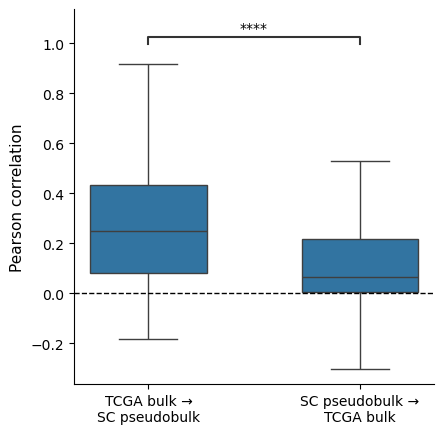

In [15]:
df=pd.read_csv("/data/kumarr17/figures_to_upload/supplementray_table/train_test_tcga_bulk_sc_pseudobulk.csv",index_col='Unnamed: 0')
# ============================================================
# 1. Convert wide dataframe to long format
# ============================================================

df_long = df[
    [
        "trained_on_TCGA_bulk_tested_on_sc",
        "sc_pseudobulk_tested_on_TCGA_bulk"
    ]
].melt(
    var_name="metric",
    value_name="value"
)

# ============================================================
# 2. Define order
# ============================================================

order = [
    "trained_on_TCGA_bulk_tested_on_sc",
    "sc_pseudobulk_tested_on_TCGA_bulk"
]

pairs = [
    (
        "trained_on_TCGA_bulk_tested_on_sc",
        "sc_pseudobulk_tested_on_TCGA_bulk"
    )
]


# ============================================================
# 3. Plot
# ============================================================

fig, ax = plt.subplots(figsize=(4.5, 5))

sns.boxplot(
    data=df_long,
    x="metric",
    y="value",
    order=order,
    showfliers=False,
    width=0.55,
    ax=ax
)


# ============================================================
# 4. Zero reference line
# ============================================================

ax.axhline(
    0,
    linestyle="--",
    color="black",
    linewidth=1
)


# ============================================================
# 5. Statistical comparison
# ============================================================

annotator = Annotator(
    ax,
    pairs,
    data=df_long,
    x="metric",
    y="value",
    order=order
)

annotator.configure(
    test="Mann-Whitney",
    text_format="star",
    loc="inside",
    verbose=0
)

annotator.apply_and_annotate()


# ============================================================
# 6. Clean labels
# ============================================================

pretty_labels = {
    "trained_on_TCGA_bulk_tested_on_sc":
        "TCGA bulk →\nSC pseudobulk",

    "sc_pseudobulk_tested_on_TCGA_bulk":
        "SC pseudobulk →\nTCGA bulk"
}

ax.set_xticklabels(
    [pretty_labels[x] for x in order],
    fontsize=10
)

ax.set_ylabel(
    "Pearson correlation",
    fontsize=11
)

ax.set_xlabel("")

ax.tick_params(
    axis="y",
    labelsize=10
)

sns.despine(ax=ax)
ax.grid(False)

fig.subplots_adjust(
    left=0.18,
    right=0.98,
    bottom=0.22,
    top=0.97
)

plt.show()

In [16]:
# Save figure as vector SVG
fig.savefig(
    "/data/kumarr17/figures_to_upload/Figure2/cross_modality_TCGA_SC_comparison.svg",
    format="svg",
    bbox_inches="tight",
    transparent=False
)

plt.show()